# Variancia Zero

In [ ]:
import pandas as pd
import numpy as np

# Criando um mini-dataset de e-commerce
dados_vendas = pd.DataFrame({
    'Preco_Produto': [100, 150, 200, 120, 180],
    'Desconto_Aplicado': [10, 15, 0, 5, 20],
    'Pais_Envio': ['Brasil', 'Brasil', 'Brasil', 'Brasil', 'Brasil'], # Variância Zero
    'Pais_Chegada': ['US', 'US', 'US', 'US', 'US'] # Variância Zero

})

print("--- Dataset Original ---")
display(dados_vendas)

var_zero = [col for col in dados_vendas.columns if dados_vendas[col].nunique() == 1]
print("\n--- Colunas com Variância Zero ---")
dados_limpos= dados_vendas.drop(columns=var_zero)
display(dados_limpos)

--- Dataset Original ---


,Preco_Produto,Desconto_Aplicado,Pais_Envio,Pais_Chegada
0,100,10,Brasil,US
1,150,15,Brasil,US
2,200,0,Brasil,US
3,120,5,Brasil,US
4,180,20,Brasil,US



--- Colunas com Variância Zero ---


,Preco_Produto,Desconto_Aplicado
0,100,10
1,150,15
2,200,0
3,120,5
4,180,20


# Baixa Variância

In [ ]:
np.random.seed(42)
dados_clientes = pd.DataFrame({
    'Idade': np.random.normal(35, 8, 1000),
    'Gasto_Mensal': np.random.normal(150, 30, 1000),
    'Usa_Plano_Premium': [0] * 995 + [1] * 5, # Baixíssima variância
    'Usa_Plano_Basic': [0] * 500 + [1] * 500 # Baixíssima variância
})
display(dados_clientes)
variancias = dados_clientes.var()
print("--- Variância ---")
print(variancias)
threshold = 0.26

colu_para_remover = variancias[variancias < threshold].index.to_list()
print("\n--- Colunas com Baixa Variância ---")
dados_limpos = dados_clientes.drop(columns=colu_para_remover)
display(dados_limpos)


,Idade,Gasto_Mensal,Usa_Plano_Premium,Usa_Plano_Basic
0,38.973713,191.980663,0,0
1,33.893886,177.739010,0,0
2,40.181508,151.788911,0,0
3,47.184239,130.591897,0,0
4,33.126773,170.946699,0,0
...,...,...,...,...
995,32.751198,182.104507,1,1
996,49.381492,149.204362,1,1
997,40.126743,123.543760,1,1
998,30.430568,145.107991,1,1


--- Variância ---
Idade                 61.367287
Gasto_Mensal         895.423711
Usa_Plano_Premium      0.004980
Usa_Plano_Basic        0.250250
dtype: float64

--- Colunas com Baixa Variância ---


,Idade,Gasto_Mensal
0,38.973713,191.980663
1,33.893886,177.739010
2,40.181508,151.788911
3,47.184239,130.591897
4,33.126773,170.946699
...,...,...
995,32.751198,182.104507
996,49.381492,149.204362
997,40.126743,123.543760
998,30.430568,145.107991


# Correlação Linear

,Horas_Estudo,Nota_Final,Faltas
0,8.741722,31.566765,14.721942
1,19.112858,77.612699,4.389837
2,15.175891,62.168926,7.821255
3,12.775853,47.531654,7.774259
4,4.808336,28.562215,16.116305
...,...,...,...
195,8.285772,26.105771,12.965291
196,15.067202,56.676588,8.688530
197,18.147985,71.524703,4.273642
198,17.967556,73.424760,5.799135



--- Matriz de Correlação ---


,Horas_Estudo,Nota_Final,Faltas
Horas_Estudo,1.000000,0.974687,-0.899759
Nota_Final,0.974687,1.000000,-0.883150
Faltas,-0.899759,-0.883150,1.000000


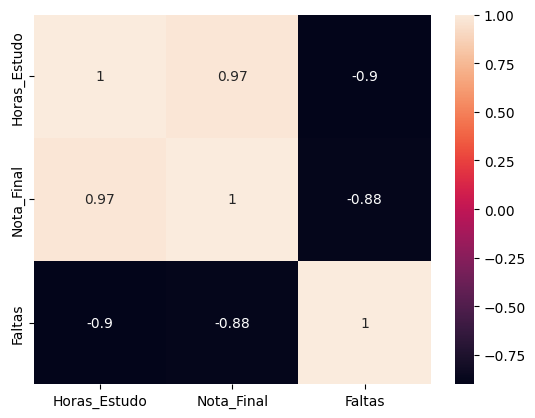

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criando dados com relações claras
np.random.seed(42)
n_amostras = 200

estudos_horas = np.random.uniform(2, 20, n_amostras)
# print("--- Horas de Estudo ---")
# print(estudos_horas)
nota_prova = (estudos_horas * 4) + np.random.normal(0, 5, n_amostras) # Correlação Positiva
faltas_aulas = 20 - (estudos_horas * 0.8) + np.random.normal(0, 2, n_amostras) # Correlação Negativa

df_escola = pd.DataFrame({
    'Horas_Estudo': estudos_horas,
    'Nota_Final': nota_prova,
    'Faltas': faltas_aulas
})

display(df_escola)
matriz_correlacao = df_escola.corr()
print("\n--- Matriz de Correlação ---")
display(matriz_correlacao)

# sns.pairplot(df_escola)
# plt.show()

sns.heatmap(matriz_correlacao, annot=True)
plt.show()

# Perigo da Multicolinearidade

In [ ]:

tamanho_m2 = np.random.normal(120, 30, 500)

df_imoveis = pd.DataFrame({
    'Area_M2': tamanho_m2,
    'Area_Pe_Quadrado': tamanho_m2 * 10.764, # Multicolinearidade Perfeita (Mesma medida, escalas diferentes)
    'Distancia_Centro_KM': np.random.uniform(1, 25, 500),
    'Preco_Venda': (tamanho_m2 * 3000) + np.random.normal(0, 20000, 500)
})
display(df_imoveis)
matriz_correlacao = df_imoveis.corr()
# print("--- Matriz de Correlação ---")
# display(matriz_correlacao)

#
matriz_correlacao_abs = df_imoveis.corr().abs()
# print("\n--- Matriz de Correlação Absoluta ---")
# display(matriz_correlacao_abs)
#
# sns.heatmap(matriz_correlacao_abs, annot=True, cmap='coolwarm')
# plt.show()

#

triangular_superior = matriz_correlacao_abs.where(np.triu(np.ones(matriz_correlacao_abs.shape), k=1).astype(bool))

colunas_redundantes = [col for col in triangular_superior.columns if any(triangular_superior[col] > 0.85)]

# print("--- Matriz de Correlação Absoluta ---")
# print(matriz_correlacao_abs.round(2))
# print(f"\nColunas recomendadas para remoção devido à Multicolinearidade: {colunas_redundantes}")

# Removendo a coluna redundante antes do Machine Learning
df_final = df_imoveis.drop(columns=colunas_redundantes)

display(df_final)

,Area_M2,Area_Pe_Quadrado,Distancia_Centro_KM,Preco_Venda
0,155.025295,1668.692272,1.802237,475689.546529
1,98.281058,1057.897309,9.802050,281574.451114
2,100.669792,1083.609641,6.689689,302760.873155
3,37.825794,407.156845,11.734551,107183.564872
4,155.584364,1674.710096,2.737033,469340.452798
...,...,...,...,...
495,160.099721,1723.313394,7.122093,473456.189176
496,166.459179,1791.766601,4.048806,503279.075061
497,129.606497,1395.084337,2.404878,399569.066108
498,156.638848,1686.060564,8.329924,458347.350534


,Area_M2,Distancia_Centro_KM
0,155.025295,1.802237
1,98.281058,9.802050
2,100.669792,6.689689
3,37.825794,11.734551
4,155.584364,2.737033
...,...,...
495,160.099721,7.122093
496,166.459179,4.048806
497,129.606497,2.404878
498,156.638848,8.329924
